# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset ini digunakan untuk membangun model machine learning yang dapat memprediksi apakah seorang nasabah akan berlangganan deposito berjangka berdasarkan karakteristik demografis, informasi pekerjaan, kondisi ekonomi, dan riwayat interaksi pemasaran sebelumnya. Dataset didapatkan dari UC ML repository(https://archive.ics.uci.edu/dataset/222/bank+marketing)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Manipulasi Data
import pandas as pd
import numpy as np

# Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve

# Pembagian Dataset
from sklearn.model_selection import train_test_split

# Model Machine Learning
from sklearn.ensemble import RandomForestClassifier

# Evaluasi Model
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Menghilangkan warning
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Konfigurasi tampilan visualisasi
sns.set_style("whitegrid")

# Ukuran default grafik
plt.rcParams['figure.figsize'] = (10, 6)

# Menampilkan seluruh kolom dataframe
pd.set_option('display.max_columns', None)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
#load dataset
df = pd.read_csv('../bank_marketing_raw/bank-full.csv', sep=';')

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

**Struktur Dataset**

In [5]:
#struktur dataset
print("Jumlah Baris dan Kolom:")
print(df.shape)

print("\nNama Kolom:")
print(df.columns.tolist())

print("\nTipe Data:")
display(df.dtypes)

print("\nInformasi Dataset:")
df.info()

Jumlah Baris dan Kolom:
(45211, 17)

Nama Kolom:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Tipe Data:


age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
#sample data
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
#Stastistik Deskriptif
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [8]:
#kategori
df.describe(include='object').T

,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


**Analisis Target**

In [9]:
#target
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [10]:
#Persentaset Target
(df['y'].value_counts(normalize=True) * 100).round(2)

y
no     88.3
yes    11.7
Name: proportion, dtype: float64

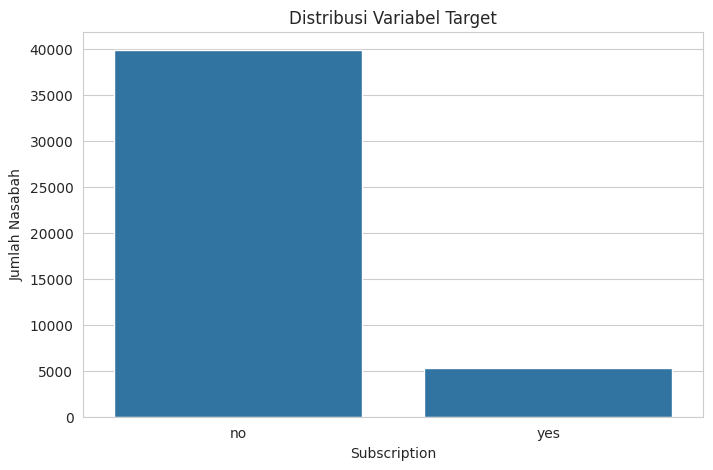

In [17]:
#visualisasi target
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='y'
)

plt.title('Distribusi Variabel Target')
plt.xlabel('Subscription')
plt.ylabel('Jumlah Nasabah')

plt.show()

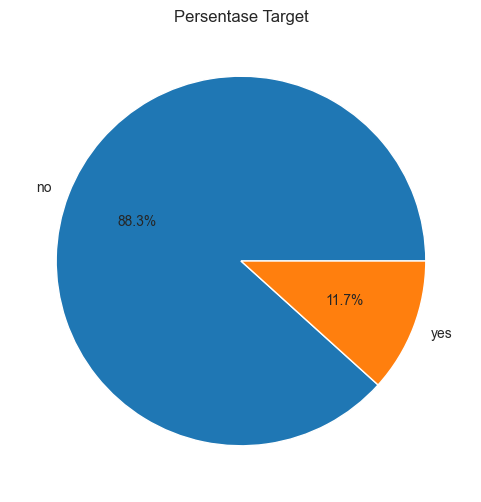

In [11]:
#visualisasi target
df['y'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.ylabel('')
plt.title('Persentase Target')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

**Missing Value**

In [12]:
missing_values = pd.DataFrame({
    'Missing Value': df.isnull().sum(),
    'Persentase (%)': (
        df.isnull().sum()
        / len(df)
        * 100
    )
})

missing_values

,Missing Value,Persentase (%)
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


**Keputusan Preprocessing**

Karena tidak terdapat missing value pada dataset, maka tahapan penanganan missing value tidak dilakukan dan dataset dapat langsung digunakan pada tahap preprocessing berikutnya.

**Data Duplikat**

In [13]:
duplicate_count = df.duplicated().sum()

print(
    f"Jumlah data duplikat: {duplicate_count}"
)

Jumlah data duplikat: 0


**Tidak ditemukan data duplikat**

# Penanganan Outlier

menggunakan IQR Capping agar informasi penting tidak hilang mengingat data perbankan secara alami memiliki distribusi yang tidak simetris.

In [14]:
def cap_outliers_iqr(df, columns):

    for col in columns:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(
            lower=lower,
            upper=upper
        )

    return df

In [15]:
#data numerik
numerical_features = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

In [16]:
#capping data
df = cap_outliers_iqr(
    df,
    numerical_features
)

In [17]:
#encoding data kategorikal
categorical_features = df.select_dtypes(
    include='object'
).columns.tolist()

categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'y']

In [18]:
#hapus data target dari kategorikal
categorical_features.remove('y')

In [19]:
#one code encoding
df = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True
)

In [20]:
#encoding target
df['y'] = df['y'].map({
    'yes':1,
    'no':0
})

In [21]:
#pisahkan target dan feature
X = df.drop(
    columns=['y']
)

y = df['y']

In [22]:
#verifikasi
print(X.shape)
print(y.shape)

(45211, 42)
(45211,)


In [23]:
# Menyimpan dataset hasil preprocessing
df.to_csv('bank_marketing_preprocessing.csv', index=False)
print("Dataset preprocessing berhasil disimpan.")


Dataset preprocessing berhasil disimpan.


In [24]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
#standarisasi data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [26]:
#hasil
print("X Train :", X_train.shape)
print("X Test  :", X_test.shape)

print("y Train :", y_train.shape)
print("y Test  :", y_test.shape)

X Train : (36168, 42)
X Test  : (9043, 42)
y Train : (36168,)
y Test  : (9043,)


Berdasarkan hasil preprocessing, tidak ditemukan missing value pada dataset sehingga tidak diperlukan proses imputasi. Data duplikat berhasil dihapus untuk menghindari bias pada model. Outlier pada fitur numerik ditangani menggunakan metode IQR Capping agar distribusi data lebih stabil tanpa kehilangan informasi penting. Seluruh fitur kategorikal ditransformasikan menggunakan One-Hot Encoding, sedangkan variabel target dikonversi menjadi format numerik. Dataset kemudian dibagi menjadi data latih dan data uji dengan rasio 80:20 serta dilakukan standarisasi pada fitur numerik untuk meningkatkan performa model machine learning.

# Modeling
Pada tahap ini dilakukan pembangunan model machine learning untuk memprediksi apakah seorang nasabah akan berlangganan deposito berjangka berdasarkan karakteristik yang dimiliki.

Model yang digunakan adalah Random Forest Classifier karena mampu menangani data dengan jumlah fitur yang cukup banyak, tahan terhadap outlier, serta memiliki performa yang baik pada permasalahan klasifikasi.

In [27]:
#inisialisasi model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [28]:
#traning model
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [29]:
#prediksi
y_pred = rf_model.predict(
    X_test
)

In [30]:
#evaluasi model
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.9040


In [31]:
#report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.65      0.39      0.48      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



Berdasarkan hasil evaluasi, model Random Forest memperoleh akurasi sebesar 90%. Namun demikian, analisis lebih lanjut menunjukkan adanya ketidakseimbangan performa antar kelas.

Model menunjukkan performa yang sangat baik dalam mengidentifikasi nasabah yang tidak berlangganan deposito (kelas 0), dengan nilai recall mencapai 97%.

Sebaliknya, performa pada kelas 1 masih relatif rendah dengan recall sebesar 39%. Hal ini menunjukkan bahwa model masih kesulitan mendeteksi nasabah yang berpotensi berlangganan deposito.

Fenomena ini kemungkinan disebabkan oleh ketidakseimbangan distribusi kelas pada dataset, di mana jumlah nasabah yang tidak berlangganan jauh lebih banyak dibandingkan nasabah yang berlangganan deposito.

In [32]:
#confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[7767,  218],
       [ 650,  408]])

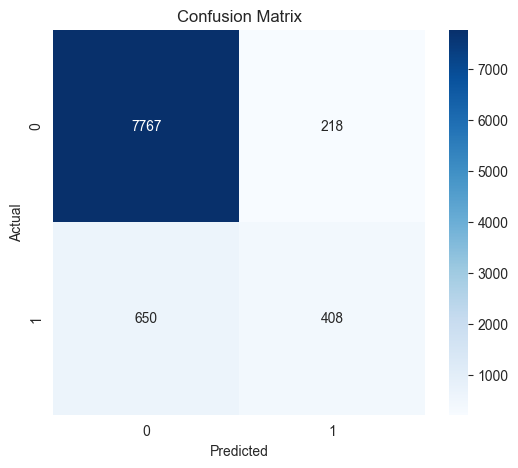

In [33]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

Berdasarkan confusion matrix, model berhasil mengklasifikasikan 7.767 nasabah yang tidak berlangganan deposito dengan benar (True Negative) dan 408 nasabah yang berlangganan deposito dengan benar (True Positive).

Namun demikian, terdapat 650 kasus False Negative, yaitu nasabah yang sebenarnya berpotensi berlangganan deposito tetapi diprediksi tidak berlangganan oleh model. Jumlah False Negative yang relatif tinggi menyebabkan nilai recall pada kelas positif menjadi rendah.

Dari perspektif bisnis, kondisi ini menunjukkan bahwa model masih berisiko kehilangan sejumlah calon pelanggan potensial yang seharusnya dapat menjadi target kampanye pemasaran bank.

In [34]:
#ROC-AUC

y_prob = rf_model.predict_proba(
    X_test
)[:,1]

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(
    f"ROC-AUC Score: {roc_auc:.4f}"
)

ROC-AUC Score: 0.9240


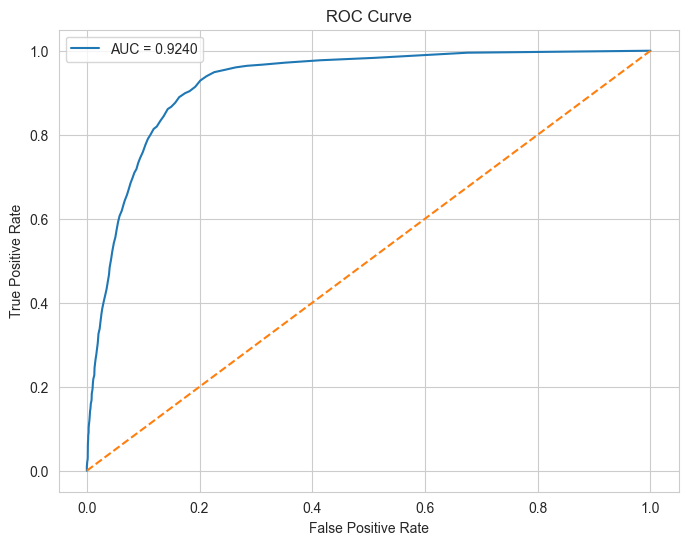

In [35]:
fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

Model Random Forest memperoleh nilai ROC-AUC sebesar 0.924 yang menunjukkan kemampuan diskriminasi yang sangat baik dalam membedakan nasabah yang berpotensi berlangganan deposito dan yang tidak.

Meskipun nilai recall pada kelas positif masih relatif rendah, nilai ROC-AUC yang tinggi mengindikasikan bahwa model telah berhasil mempelajari pola yang relevan dari data. Rendahnya recall kemungkinan disebabkan oleh penggunaan threshold prediksi standar sebesar 0.5 serta adanya ketidakseimbangan distribusi kelas pada dataset.

In [36]:
#feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,duration,0.255817
0,age,0.108534
1,balance,0.107183
2,day,0.100237
40,poutcome_success,0.059947
4,campaign,0.042726
41,poutcome_unknown,0.021346
24,housing_yes,0.020671
27,contact_unknown,0.015746
20,education_secondary,0.014954


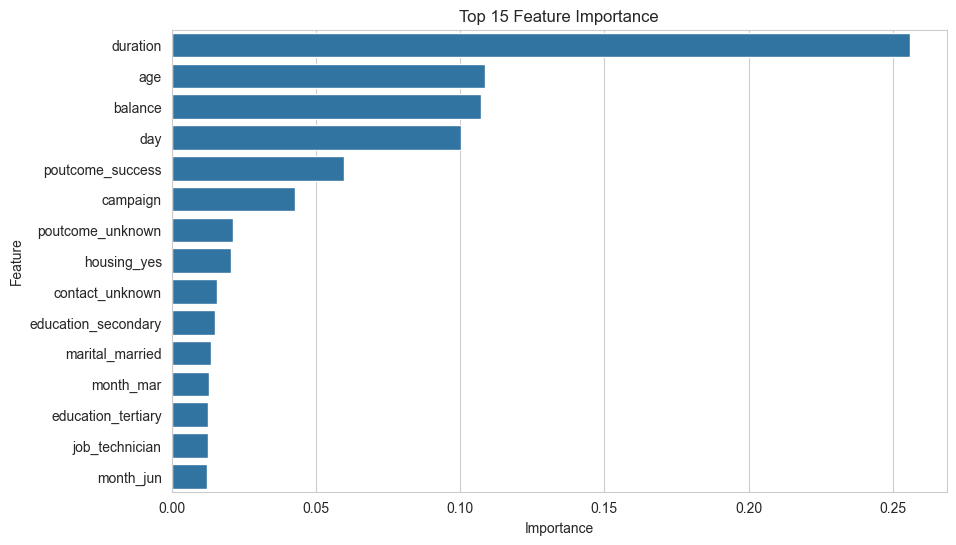

In [37]:
#visualisasi
sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Feature Importance')
plt.show()

Berdasarkan analisis feature importance dari model Random Forest, fitur duration menjadi variabel yang paling berpengaruh terhadap prediksi keputusan nasabah dengan nilai importance sebesar 25,58%.

Selain itu, fitur age, balance, dan day juga memberikan kontribusi yang cukup besar dalam proses prediksi. Hasil ini menunjukkan bahwa karakteristik demografis dan kondisi finansial nasabah memiliki hubungan yang kuat dengan keputusan untuk berlangganan deposito.

Fitur poutcome_success juga menunjukkan importance yang tinggi, yang mengindikasikan bahwa keberhasilan kampanye pemasaran sebelumnya dapat menjadi indikator penting dalam memprediksi respons nasabah terhadap kampanye berikutnya.

Secara keseluruhan, model berhasil mengidentifikasi kombinasi faktor demografis, finansial, dan riwayat pemasaran sebagai penentu utama keberhasilan kampanye deposito bank.

# Kesimpulan
**Berdasarkan hasil eksperimen yang dilakukan pada Bank Marketing Dataset, model Random Forest berhasil mencapai akurasi sebesar 90% dengan ROC-AUC sebesar 0.924. Hasil tersebut menunjukkan bahwa model memiliki kemampuan yang sangat baik dalam membedakan nasabah yang berpotensi berlangganan deposito dan yang tidak.

Hasil EDA menunjukkan bahwa dataset tidak memiliki missing value, namun terdapat beberapa outlier pada fitur numerik yang telah ditangani menggunakan metode IQR Capping. Selain itu, fitur kategorikal berhasil ditransformasikan menggunakan One-Hot Encoding sehingga dapat digunakan oleh algoritma machine learning.**